# Imports

In [ ]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2


import numpy as np
import scipy
from scipy.sparse.linalg import splu
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import tqdm
import h5py

import chladni_eigenmodes.fem_utils as fem_utils

import numpy as np
import meshio
from shapely.geometry import Polygon
from collections import defaultdict
from shapely.geometry import Point, LineString
from shapely.ops import polygonize, unary_union, nearest_points
from shapely.prepared import prep
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.tri as tri

import skfem
from skfem import MeshTri, Basis, ElementTriP1
from skfem.helpers import grad, dot
from skfem.models.poisson import laplace, mass

# Definitions

In [ ]:
# Load FEM solution for eigenmode data

def load_fem_solution_hdf5(filename):
    """Load FEM solution from HDF5 file."""
    with h5py.File(filename, "r") as f:
        points = np.array(f["mesh/points"])
        triangles = np.array(f["mesh/triangles"])
        eigenvalues = np.array(f["modes/eigenvalues"])
        eigenvectors = np.array(f["modes/eigenvectors"])
        metadata = {
            "source_mesh_file": f.attrs.get("source_mesh_file", ""),
            "source_mesh_name": f.attrs.get("source_mesh_name", ""),
            "n_points": int(f.attrs.get("n_points", points.shape[0])),
            "n_triangles": int(f.attrs.get("n_triangles", triangles.shape[0])),
            "n_modes": int(f.attrs.get("n_modes", eigenvectors.shape[0])),
        }
    return {
        "points": points,
        "triangles": triangles,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "metadata": metadata,
    }
    
def normalize_density(rho, M):
    ones = np.ones_like(rho)
    mass = ones @ (M @ rho)
    return rho / mass

# Simulation

## Load FEM data

Numer of eigenmodes in FEM data: 100



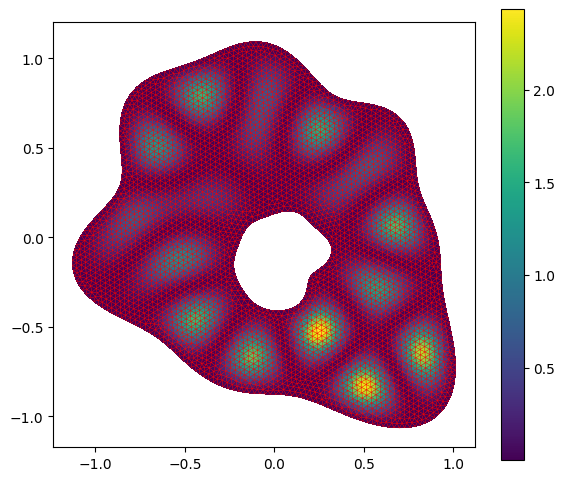

In [ ]:
# Load FEM solution and select an eigenmode
fem_file = "/home/jlangbehn/documents/private/generative_art/chladni_eigenmodes/output/random_shape_fem.h5"
fem_data = load_fem_solution_hdf5(fem_file)
print(f"Numer of eigenmodes in FEM data: {len(fem_data['eigenvectors'])}")
mesh_io = meshio.read(fem_data["metadata"]["source_mesh_file"])

# Select the eigenmode to use (0 = first mode)
mode_idx = 20
eigenmode = fem_data["eigenvectors"][mode_idx]

mesh_points, mesh_triangles = fem_utils.meshio_to_points_triangles(mesh_io)

triang = tri.Triangulation(mesh_points[:, 0], mesh_points[:, 1], mesh_triangles)
V = np.abs(eigenmode)**2

fig, ax = plt.subplots(figsize=(6, 5))
tcf = ax.tripcolor(triang, V, cmap='viridis')
for t in mesh_triangles:
    triangle = mesh_points[t]
    ax.plot(*np.vstack([triangle, triangle[0]]).T, color='r', linewidth=0.2)
#ax.scatter(mesh_points[:, 0], mesh_points[:, 1], s=1, color='r')
ax.set_aspect('equal')
plt.colorbar(tcf, ax=ax)
plt.tight_layout()
plt.show()

eigenmode_field = fem_utils.EigenmodePotentialField(mesh_points, mesh_triangles, eigenmode)

## Assemble advection-diffusion system

In [ ]:
def assemble_advection_matrix(basis, epot_field):
    """Assemble the advection matrix A for the given basis and velocity field."""
    X = basis.global_coordinates()   # shape: (2, n_qp, n_elem)

    x_flat = X[0].ravel()
    y_flat = X[1].ravel()

    vel_flat = np.array([
        epot_field.gradient(x, y)
        for x, y in zip(x_flat, y_flat)
    ])   # shape: (n_qp * n_elem, 2)

    velocity = vel_flat.T.reshape((2,) + X.shape[1:])

    @skfem.BilinearForm
    def advect(rho, test, w):
        return rho * dot(w["velocity"], grad(test))
    
    A = skfem.asm(advect, basis, velocity=velocity)
    return A

mesh_skfem = MeshTri(mesh_points.T, mesh_triangles.T)

# P1 basis
basis = Basis(mesh_skfem, ElementTriP1())

X = basis.global_coordinates()   # shape: (2, n_qp, n_elem)

A = assemble_advection_matrix(basis, eigenmode_field)
A2 = assemble_advection_matrix(basis, fem_utils.EigenmodePotentialField(mesh_points, mesh_triangles, fem_data["eigenvectors"][30]))
K = skfem.asm(laplace, basis)
M = skfem.asm(mass, basis)

Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


## Compute steady state solution (linear algebra)

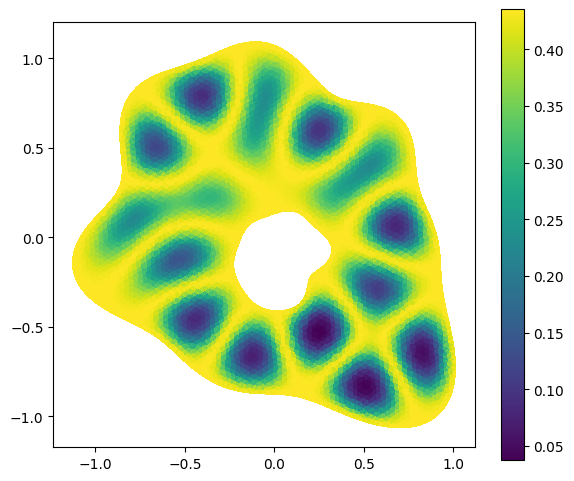

In [12]:
D = 1
L = -A - D * K

# find eigenvector with eigenvalue closest to zero
evals, evecs = scipy.sparse.linalg.eigs(L, k=1, sigma=0.0)

rho_stat = np.real(evecs[:, 0])

# fix sign
if rho_stat.mean() < 0:
    rho_stat *= -1

# remove small negative numerical artifacts
rho_stat = np.maximum(rho_stat, 0.0)
rho_stat = normalize_density(rho_stat, M)

fig, ax = plt.subplots(figsize=(6, 5))
tcf = ax.tripcolor(triang, rho_stat, cmap='viridis')
ax.set_aspect('equal')
plt.colorbar(tcf, ax=ax)
plt.tight_layout()
plt.show()

## Compute steady state solution (time-evolution)

100%|██████████| 1000/1000 [00:00<00:00, 4110.61it/s]


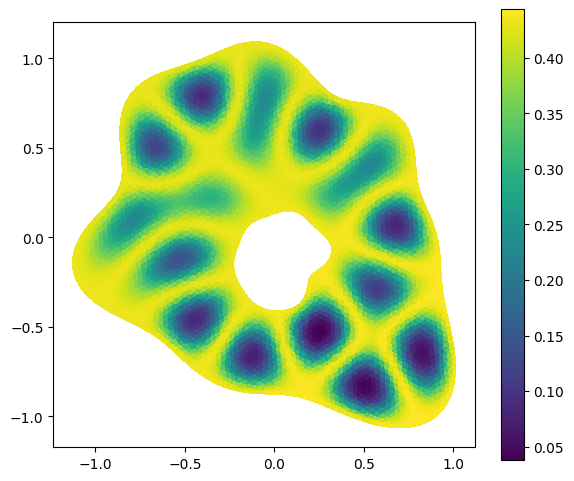

In [ ]:
dt = 1e-3
n_steps = 1000

LHS = M + dt * D * K
solver = splu(LHS.tocsc())


rho0 = np.ones(M.shape[0])
rho0 = normalize_density(rho0, M)

rho = rho0.copy()

for _ in tqdm.tqdm(range(n_steps), total=n_steps):
    rhs = M @ rho + dt * (-A @ rho)
    rho = solver.solve(rhs)

    # optional visual/numerical cleanup
    rho = np.maximum(rho, 0.0)
    rho = normalize_density(rho, M)

fig, ax = plt.subplots(figsize=(6, 5))
tcf = ax.tripcolor(triang, rho, cmap='viridis')
ax.set_aspect('equal')
plt.colorbar(tcf, ax=ax)
plt.tight_layout()
plt.show()

## Animate time-evolution

In [ ]:
# parameters
dt = 1e-4
n_steps = 100
steps_per_frame = 1
n_frames = n_steps // steps_per_frame

# solver
LHS = M + dt * D * K
solver = splu(LHS.tocsc())

# initial density
rho0 = np.ones(M.shape[0])
rho0 = normalize_density(rho0, M)
rho = rho0.copy()
i_step = 0

# optional: fix color scale manually
vmin = 0.0
vmax = None  # set later after warmup or use fixed value

fig, ax = plt.subplots(figsize=(6, 5))
tcf = ax.tripcolor(triang, rho, cmap="viridis", shading="gouraud", vmin=vmin, vmax=vmax)

ax.set_aspect("equal")
ax.set_axis_off()
cbar = plt.colorbar(tcf, ax=ax)

def step_density(rho):
    global i_step
    if i_step < n_steps /2:
        rhs = M @ rho + dt * (-A @ rho)
    else:
        rhs = M @ rho + dt * (-A2 @ rho)
    rho_new = solver.solve(rhs)

    # optional cleanup
    rho_new = np.maximum(rho_new, 0.0)
    rho_new = normalize_density(rho_new, M)

    i_step += 1
    return rho_new

def update(frame):
    global rho, tcf, i_step

    # update plot
    tcf.set_array(rho)

    for _ in range(steps_per_frame):
        rho = step_density(rho)

    
    ax.set_title(f"t = {frame * steps_per_frame * dt:.3f}")
    return (tcf,)

anim = FuncAnimation(
    fig,
    update,
    frames=tqdm.tqdm(range(n_frames)),
    interval=30,
    blit=False,
)

file_name = "/home/jlangbehn/documents/private/generative_art/chladni_eigenmodes/output/density_evolution.mp4"
writer = FFMpegWriter(fps=30, bitrate=3000)
anim.save(file_name, writer=writer)

plt.close(fig)

  0%|          | 0/100 [00:00<?, ?it/s]

 99%|█████████▉| 99/100 [00:02<00:00, 35.55it/s]

 99%|█████████▉| 99/100 [00:20<00:00, 35.55it/s]